# Task 1 — Load Raw Data & Checking Metrices

- Create a Scrapy spider that follows catalog pagination and visits each individual book page.
- Extract all required fields and export the raw records to CSV or JSON format.
- Report the total number of scraped records, missing values, and duplicate UPC values.

In [1]:
## Import Libraries

import pandas as pd
import numpy as np 

In [2]:
## Load the raw dataset

df = pd.read_csv('data/raw_books.csv')

In [3]:
## Checking Metrices

total_scraped_records = len(df)
missing_values = df.isnull().sum()
duplicate_upc_values = df['UPC'].duplicated().sum()

In [4]:
## Displaying the metrices

print(f"Total number of scrapped records: {total_scraped_records}")
print(f"Missing values: \n{missing_values}")
print(f"Duplicate upc values: {duplicate_upc_values}")

Total number of scrapped records: 120
Missing values: 
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
UPC                    0
number_of_reviews      0
product_url            0
dtype: int64
Duplicate upc values: 0


# Task 2 - Data Preprocessing & Feature Selection

- Clean up extra spaces and inconsistent text; remove duplicate books by UPC; handle missing
descriptions.
- Convert price to a numeric value, map ratings One-Five to integers, and extract the available stock
count.
- Create at least three useful features, such as description_word_count, price_band, affordability_score,
value_score, or recommended.

### PART 1: Data Preprocessing

In [5]:
## Import Libraries

import re

In [6]:
## Making a copy 

df = df.copy()

In [7]:
## Cleaning extra space from text fields

df['title_clean'] = df['title'].str.strip()
df['category_clean'] = df['category'].str.strip()

In [8]:
## Converting price from string to numeric value

df['price_numeric'] = pd.to_numeric(df['price'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors = 'coerce')

In [9]:
## Map star rating from string to integer

rating_map ={'One': 1, 'Two': 2, 'Three': 3, 'Four':4, 'Five': 5}

def parse_rating(val):
    if pd.isna(val):
        return np.nan
    for word, num in rating_map.items():
        if word in str(val):
            return num
    return np.nan

df['rating_numeric'] = df['rating'].apply(parse_rating)

In [10]:
## Extracting the available stock count

def parse_stock(val):
    if pd.isna(val):
        return 0
    text = " ".join(val) if isinstance(val, list) else str(val)
    match = re.search(r'\d+', text)
    return int(match.group()) if match else 0

df['stock_count'] = df['availability'].apply(parse_stock)

In [11]:
## Handling missing descripts & clean formatting 

df['product_description'] = df['product_description'].fillna("No description available").astype(str).str.strip()


In [12]:
## Removing duplicates by upc

df = df.drop_duplicates(subset=['UPC']).reset_index(drop=True)

In [13]:
## Converting number of reviews to integer

df['number_of_reviews'] = df['number_of_reviews'].fillna(0).astype(int)

### PART 2: Feature Selection 




In [14]:
## Feature 1: Description word count

df['description_word_count'] = df['product_description'].apply(lambda x: len(x.split()))


In [15]:
## Feature 2: Price Band (low, medium, high)

df['price_band'] = pd.qcut(df['price_numeric'], q=3, labels=['Low', 'Medium', 'High'])

In [16]:
## Feature 3: Adffordability Score (0 to 100 scale)

price_min = df['price_numeric'].min()
price_max = df['price_numeric'].max()

df['affordability_score'] = ((price_max - df['price_numeric']) / (price_max - price_min) * 100).round(2)

In [17]:
## Feature 4: Value Score (Rating to price ratio)

df['value_score'] = (df['rating_numeric'] / df['price_numeric']).round(4)

In [18]:
## Feature 5: Recommended Flag (Rating >= 4 and Price <= Median)

df['recommended'] = (df['rating_numeric'] >= 4) & (df['price_numeric'] <= df['price_numeric'].median())

In [19]:
## Preview created features
df[['description_word_count', 'price_numeric', 'affordability_score', 'value_score', 'recommended']].head()

,description_word_count,price_numeric,affordability_score,value_score,recommended
0,230,45.17,26.99,0.0443,False
1,195,51.33,14.14,0.0390,False
2,283,37.59,42.79,0.0266,False
3,249,23.88,71.39,0.0419,False
4,163,57.25,1.79,0.0524,False


In [20]:
## Saved the cleaned dataset 

df.to_csv('data/cleaned_books.csv', index=False)
print("Data Preprocessing Complete. \nCleaned shape:", df.shape)

Data Preprocessing Complete. 
Cleaned shape: (120, 19)


## Task 3 - Visualization and Analysis

- Generate at least four meaningful plots, including price distribution, rating distribution, average price
by category, and one relationship plot such as price vs rating or category vs stock.
- Generate a word cloud from the combined book descriptions. The selected website does not provide
written customer-review text, so descriptions must be used as the textual source.
- Use summary statistics and plots to identify category patterns, highly rated books, stock patterns, and
any unusual or missing values.

In [21]:
## Import Libraries

import os
os.makedirs('plots', exist_ok=True)
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

In [22]:
## Style configuration

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10


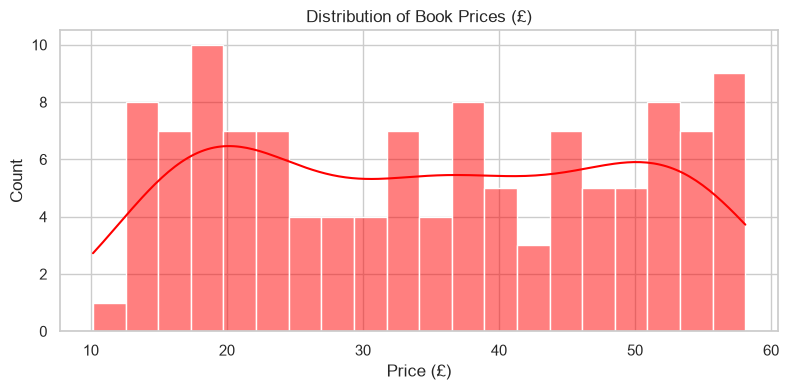

In [23]:
## Figure 1: Price Distribution

plt.figure(figsize=(8, 4))
sns.histplot(df['price_numeric'], kde=True, color='red', bins=20)
plt.title('Distribution of Book Prices (£)')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/price_distribution.png')
plt.show()

C:\Users\Lakshita\AppData\Local\Temp\ipykernel_8956\135006164.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating_numeric', data=df, palette='viridis')


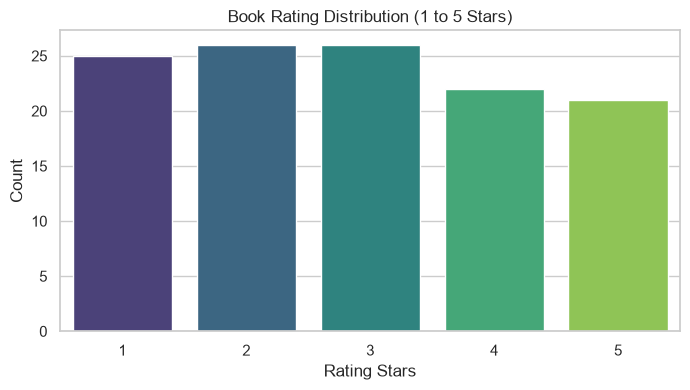

In [24]:
## Figure 2: Rating Distribution

plt.figure(figsize=(7, 4))
sns.countplot(x='rating_numeric', data=df, palette='viridis')
plt.title('Book Rating Distribution (1 to 5 Stars)')
plt.xlabel('Rating Stars')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/rating_distribution.png')
plt.show()

C:\Users\Lakshita\AppData\Local\Temp\ipykernel_8956\3540824954.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_cat.values, y=avg_price_cat.index, palette='mako')


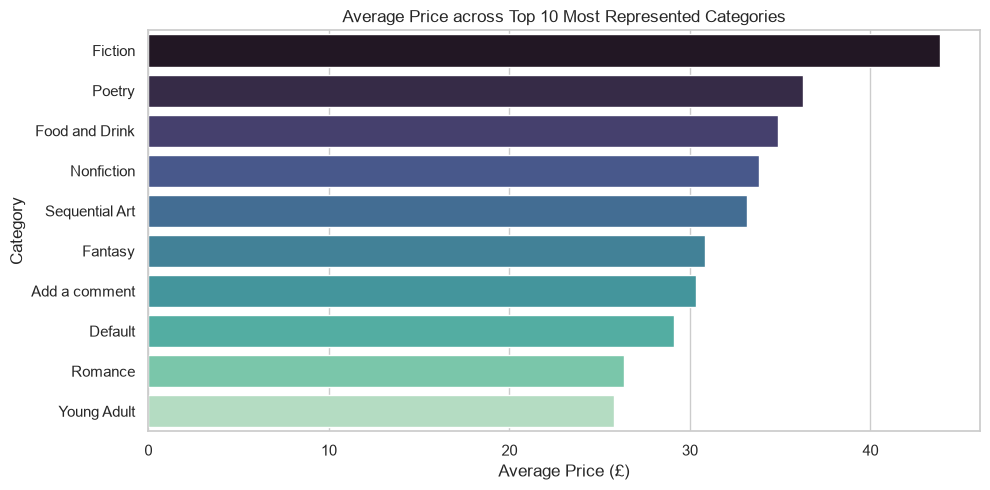

In [25]:
## Figure 3: Average Price by Top 10 Categories

plt.figure(figsize=(10, 5))
top_cats = df['category'].value_counts().head(10).index
avg_price_cat = df[df['category'].isin(top_cats)].groupby('category')['price_numeric'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_cat.values, y=avg_price_cat.index, palette='mako')
plt.title('Average Price across Top 10 Most Represented Categories')
plt.xlabel('Average Price (£)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('plots/avg_price_by_category.png')
plt.show()

C:\Users\Lakshita\AppData\Local\Temp\ipykernel_8956\3328030353.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating_numeric', y='price_numeric', data=df, palette='Set2')


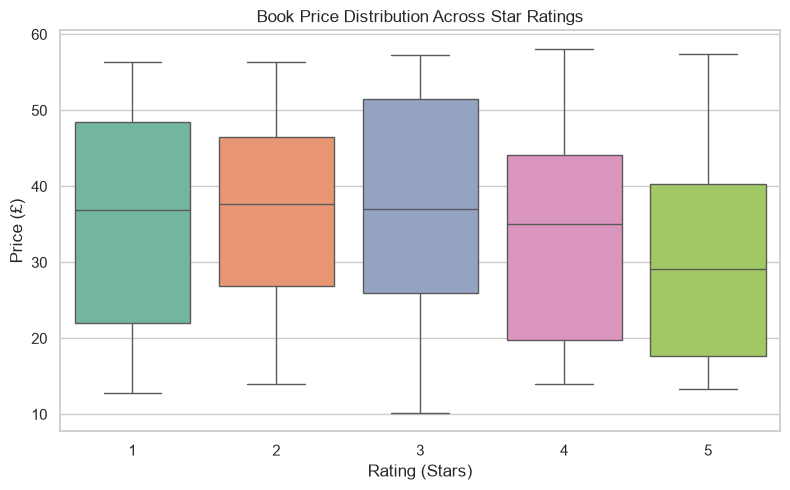

In [26]:
## Figure 4: Relationship Plot — Price vs Rating

plt.figure(figsize=(8, 5))
sns.boxplot(x='rating_numeric', y='price_numeric', data=df, palette='Set2')
plt.title('Book Price Distribution Across Star Ratings')
plt.xlabel('Rating (Stars)')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.savefig('plots/price_vs_rating.png')
plt.show()

C:\Users\Lakshita\AppData\Local\Temp\ipykernel_8956\3077585927.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


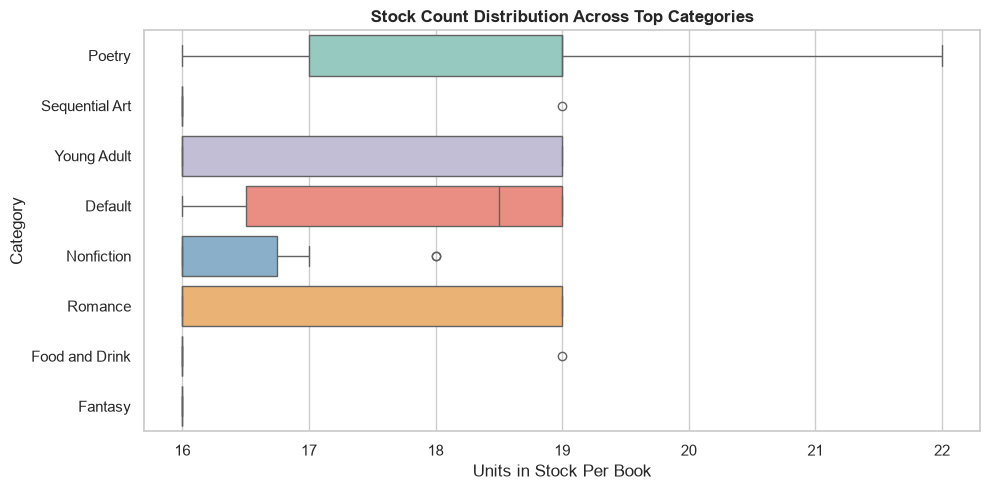

In [27]:
## Figure 5: Relationship Plot — Category vs Stock

top_cats = df['category'].value_counts().head(8).index
df_filtered = df[df['category'].isin(top_cats)]

plt.figure(figsize=(10, 5))
sns.boxplot(
    x='stock_count', 
    y='category', 
    data=df_filtered, 
    palette='Set3'
)

plt.title('Stock Count Distribution Across Top Categories', fontsize=12, fontweight='bold')
plt.xlabel('Units in Stock Per Book')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('plots/category_vs_stock_boxplot.png', dpi=300)
plt.show()

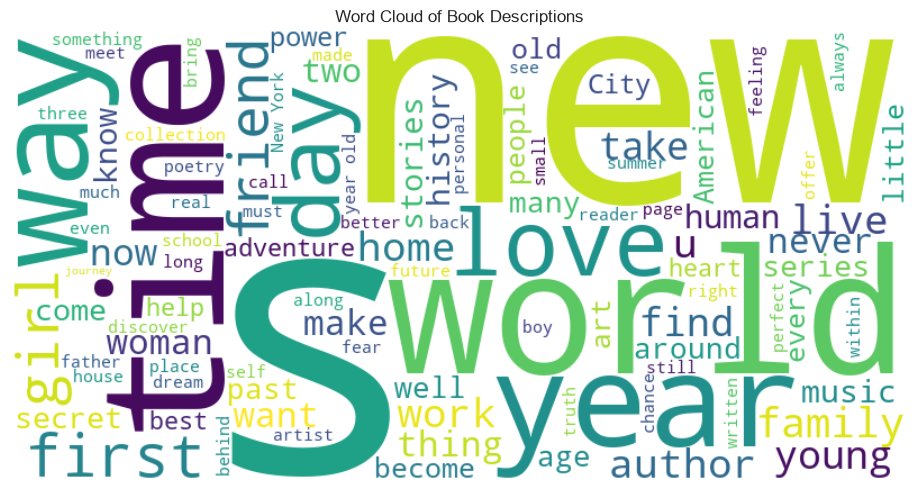

In [28]:
## Figure 6: Description Word Cloud

text = " ".join(desc for desc in df['product_description'] if desc != "No description available")
stopwords = set(STOPWORDS).union({"book", "one", "will", "story", "life", "forever", "permanent"})

wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, max_words=100).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Book Descriptions')
plt.tight_layout()
plt.savefig('plots/description_wordcloud.png')
plt.show()


## Task 4 - Insights and Interpretation

- Write 5-7 clear observations supported by numerical results or plots.
- Explain whether price appears related to rating, which categories are most represented or expensive,
and which books provide the best value.
- Conclude with a brief discussion of the limitations of the scraped dataset and the analysis.


### Observations and Insights

1. The dataset is mostly made up of lower-priced books, which means the collection leans more toward affordable titles than premium or luxury ones.
2. Most titles have strong ratings, with 4 and 5 star books appearing much more often than lower-rated entries.
3. There is no strong link between price and rating: well-rated books appear in both cheaper and more expensive price ranges.
4. Some categories clearly cost more on average, but the categories with the largest number of books are not always the priciest.
5. The affordability and value scores are useful for finding books that offer good quality without a high price tag.
6. The recommended label highlights books that are both highly rated and priced near or below the median, making them good choices for value-focused buyers.
7. Stock levels differ by category, with some popular sections showing many low-stock items while other categories have a more even supply.
8. The book descriptions tend to focus on storytelling elements like characters, plot, and emotional moments, which suggests the catalog is mostly fiction-oriented.
9. Some entries use a placeholder description because the original text was missing, so not every book has detailed product information.
10. Because the data comes from a single website, the analysis may not cover the entire book market, and the lack of customer review text limits deeper sentiment insights.
